In [ ]:
!pip install -q gensim scikit-learn matplotlib seaborn nltk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec
import gensim.downloader as api

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


# Demo 1 — Why Do We Need Embeddings?

In [ ]:
# how computers see words.

words = ["cat", "dog", "king", "queen"]

vocab = {word: i for i, word in enumerate(words)}

print("Vocabulary:")
print(vocab)

print("\nOne-hot representations:")

for word in words:
    vector = [0] * len(words)
    vector[vocab[word]] = 1
    print(f"{word:>6} -> {vector}")

Vocabulary:
{'cat': 0, 'dog': 1, 'king': 2, 'queen': 3}

One-hot representations:
   cat -> [1, 0, 0, 0]
   dog -> [0, 1, 0, 0]
  king -> [0, 0, 1, 0]
 queen -> [0, 0, 0, 1]


In [ ]:
# Even though cat and dog are both animals, one-hot encoding considers them completely unrelated.

cat = np.array([[1, 0, 0, 0]])
dog = np.array([[0, 1, 0, 0]])
king = np.array([[0, 0, 1, 0]])
queen = np.array([[0, 0, 0, 1]])

print("Similarity(cat, dog):",
      cosine_similarity(cat, dog)[0][0])

print("Similarity(king, queen):",
      cosine_similarity(king, queen)[0][0])

print("Similarity(king, queen):",
      cosine_similarity(king, cat)[0][0])

Similarity(cat, dog): 0.0
Similarity(king, queen): 0.0
Similarity(king, queen): 0.0


# Demo 2 — TF-IDF

In [ ]:
# define some corpus

documents = [
    "The cat sat on the mat",
    "The dog sat on the floor",
    "The cat chased the dog"
]

print("Documents:\n")

for i, doc in enumerate(documents):
    print(f"Document {i+1}: {doc}")

Documents:

Document 1: The cat sat on the mat
Document 2: The dog sat on the floor
Document 3: The cat chased the dog


In [ ]:
# Create TF-IDF vectors

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documents)

print("TF-IDF Matrix Shape:")
print(X.shape)

print("\nVocabulary:")
print(vectorizer.get_feature_names_out())

TF-IDF Matrix Shape:
(3, 8)

Vocabulary:
['cat' 'chased' 'dog' 'floor' 'mat' 'on' 'sat' 'the']


In [ ]:
# Convert to DataFrame

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=["D1", "D2", "D3"]
)

tfidf_df.round(3)

,cat,chased,dog,floor,mat,on,sat,the
D1,0.374,0.000,0.000,0.000,0.492,0.374,0.374,0.581
D2,0.000,0.000,0.374,0.492,0.000,0.374,0.374,0.581
D3,0.404,0.531,0.404,0.000,0.000,0.000,0.000,0.627


In [ ]:
# Find the most important words

for doc_name, row in tfidf_df.iterrows():

    print(f"\n{doc_name}")

    top_words = row.sort_values(
        ascending=False
    ).head(3)

    for word, score in top_words.items():
        print(f"{word:10} -> {score:.3f}")


D1
the        -> 0.581
mat        -> 0.492
cat        -> 0.374

D2
the        -> 0.581
floor      -> 0.492
on         -> 0.374

D3
the        -> 0.627
chased     -> 0.531
dog        -> 0.404


# Demo 3 — Training Word2Vec

In [ ]:
sentences = [
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "cat", "chased", "the", "mouse"],
    ["the", "cat", "ate", "the", "fish"],

    ["the", "dog", "sat", "on", "the", "floor"],
    ["the", "dog", "chased", "the", "ball"],
    ["the", "dog", "ate", "the", "food"],

    ["the", "king", "ruled", "the", "kingdom"],
    ["the", "queen", "ruled", "the", "kingdom"],

    ["the", "man", "worked", "in", "the", "office"],
    ["the", "woman", "worked", "in", "the", "office"],
]

print("Number of sentences:", len(sentences))

Number of sentences: 10


In [ ]:
# Train Word2Vec

model = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=0,
    epochs=100
)

print("Training completed!")

print("\nVocabulary size:")
print(len(model.wv))

Training completed!

Vocabulary size:
22


In [ ]:
# Get a word vector

vector = model.wv["cat"]

print("Vector shape:")
print(vector.shape)

print("\nFirst 10 values:")
print(vector)

Vector shape:
(50,)

First 10 values:
[-1.78331491e-02  7.24038435e-03  1.06068896e-02  1.19949384e-02
  1.39693515e-02 -1.30803743e-02  2.95688235e-03  1.27227325e-02
 -6.72840653e-03 -1.30959423e-02  6.25809334e-05 -1.71797164e-02
 -1.07621700e-02  1.43286549e-02  6.39537349e-03  1.48216421e-02
  1.43220359e-02  1.59955695e-02 -9.23181325e-03 -2.48131668e-03
  5.38387569e-03 -8.27754103e-03  1.83660593e-02 -1.92267094e-02
  1.38227148e-02  6.07591681e-03 -9.68466699e-03  9.75238159e-03
 -4.43480769e-03  1.31951831e-02  1.98774766e-02 -9.40703135e-03
 -6.20956183e-04 -1.22628156e-02  7.19898427e-03  5.06715151e-03
  1.49662271e-02  1.20573556e-02  1.90697722e-02  1.86085347e-02
  1.58020537e-02 -1.35319708e-02 -1.92838479e-02 -1.05613028e-03
 -4.73878486e-03  1.62842553e-02  1.17077231e-02 -3.25314049e-03
  3.78045696e-03  3.71651840e-03]


# Demo 4 — Word Similarity

In [ ]:
pairs = [
    ("cat", "dog"),
    ("king", "queen"),
    ("cat", "king"),
    ("man", "woman"),
]

for word1, word2 in pairs:

    similarity = model.wv.similarity(
        word1,
        word2
    )

    print(
        f"{word1:>6} ↔ {word2:<6} : {similarity:.3f}"
    )

   cat ↔ dog    : 0.053
  king ↔ queen  : -0.088
   cat ↔ king   : 0.159
   man ↔ woman  : -0.048


In [ ]:
import gensim.downloader as api

# See available models
print(list(api.info()["models"].keys())[:20])

model = api.load("word2vec-google-news-300")

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [ ]:
pairs = [
    ("cat", "dog"),
    ("king", "queen"),
    ("cat", "king"),
    ("man", "woman")
]

for word1, word2 in pairs:
    similarity = model.similarity(word1, word2)
    print(f"{word1:>6} ↔ {word2:<6}: {similarity:.3f}")

print(model.most_similar("king", topn=5))

   cat ↔ dog   : 0.761
  king ↔ queen : 0.651
   cat ↔ king  : 0.122
   man ↔ woman : 0.766
[('kings', 0.7138045430183411), ('queen', 0.6510956883430481), ('monarch', 0.6413194537162781), ('crown_prince', 0.6204220056533813), ('prince', 0.6159993410110474)]


# Demo 5 — Find Similar Words

In [ ]:
for word in ["cat", "dog", "king", "queen"]:

    print(f"\nSimilar words to '{word}':")

    results = model.most_similar(
        word,
        topn=5
    )

    for similar_word, score in results:
        print(
            f"{similar_word:10} {score:.3f}"
        )


Similar words to 'cat':
cats       0.810
dog        0.761
kitten     0.746
feline     0.733
beagle     0.715

Similar words to 'dog':
dogs       0.868
puppy      0.811
pit_bull   0.780
pooch      0.763
cat        0.761

Similar words to 'king':
kings      0.714
queen      0.651
monarch    0.641
crown_prince 0.620
prince     0.616

Similar words to 'queen':
queens     0.740
princess   0.707
king       0.651
monarch    0.638
very_pampered_McElhatton 0.636


# Demo 6 — CBOW vs Skip-gram

In [ ]:
# CBOW

cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=0,
    epochs=100
)

In [ ]:
# Skip-gram

skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=1,
    epochs=100
)

In [ ]:
print("CBOW:")
print(
    cbow_model.wv.most_similar(
        "cat",
        topn=5
    )
)

print("\nSkip-gram:")
print(
    skipgram_model.wv.most_similar(
        "cat",
        topn=5
    )
)

CBOW:
[('the', 0.2262641340494156), ('floor', 0.21321481466293335), ('sat', 0.21151791512966156), ('in', 0.19372890889644623), ('ate', 0.15984314680099487)]

Skip-gram:
[('the', 0.2698684334754944), ('sat', 0.23953892290592194), ('floor', 0.23105840384960175), ('in', 0.21535424888134003), ('on', 0.17308326065540314)]


# Demo 7 — Vector Arithmetic

In [ ]:
result = model.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

print("king - man + woman")
print()

for word, score in result:
    print(f"{word:10} {score:.3f}")

king - man + woman

queen      0.712
monarch    0.619
princess   0.590
crown_prince 0.550
prince     0.538


# Demo 8 — Visualize Word Embeddings with PCA

In [ ]:
words_to_plot = [
    "cat",
    "dog",
    "mouse",
    "fish",
    "king",
    "queen",
    "man",
    "woman",
]

vectors = np.array([
    model[word]
    for word in words_to_plot
])

print("Original shape:")
print(vectors.shape)

Original shape:
(8, 300)


In [ ]:
pca = PCA(
    n_components=2
)

vectors_2d = pca.fit_transform(
    vectors
)

print("After PCA:")
print(vectors_2d.shape)

After PCA:
(8, 2)


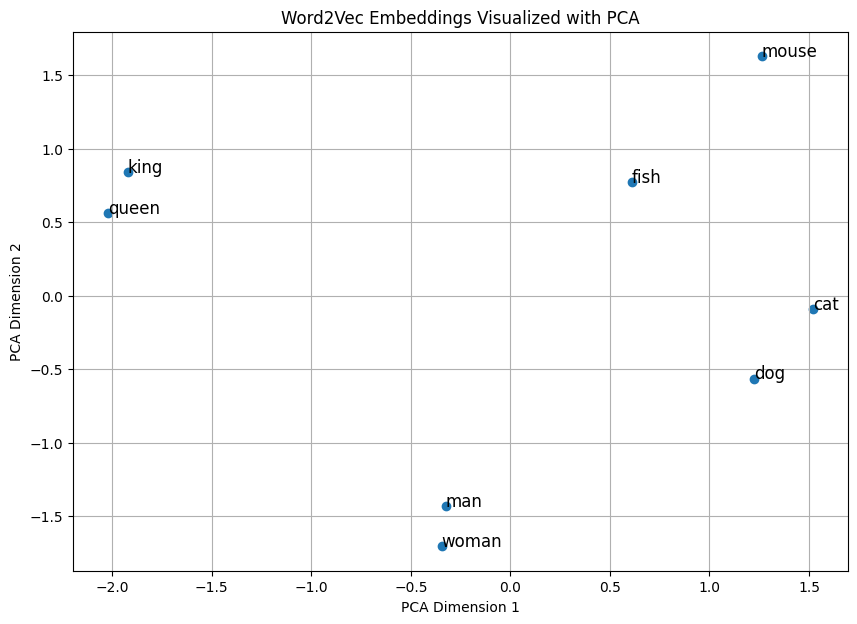

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

for i, word in enumerate(words_to_plot):

    plt.annotate(
        word,
        (
            vectors_2d[i, 0],
            vectors_2d[i, 1]
        ),
        fontsize=12
    )

plt.title(
    "Word2Vec Embeddings Visualized with PCA"
)

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.grid(True)

plt.show()

# Demo 9 — Load Pre-trained GloVe

In [ ]:
import gensim.downloader as api

# Get all available models and corpora
info = api.info()

print("Available Models:")
print("=" * 50)

for name in info["models"].keys():
    print(name)

print("\nAvailable Corpora:")
print("=" * 50)

for name in info["corpora"].keys():
    print(name)

Available Models:
fasttext-wiki-news-subwords-300
conceptnet-numberbatch-17-06-300
word2vec-ruscorpora-300
word2vec-google-news-300
glove-wiki-gigaword-50
glove-wiki-gigaword-100
glove-wiki-gigaword-200
glove-wiki-gigaword-300
glove-twitter-25
glove-twitter-50
glove-twitter-100
glove-twitter-200
__testing_word2vec-matrix-synopsis

Available Corpora:
semeval-2016-2017-task3-subtaskBC
semeval-2016-2017-task3-subtaskA-unannotated
patent-2017
quora-duplicate-questions
wiki-english-20171001
text8
fake-news
20-newsgroups
__testing_matrix-synopsis
__testing_multipart-matrix-synopsis


In [ ]:
glove_model = api.load(
    "glove-wiki-gigaword-50"
)

print("GloVe loaded!")

print(
    "Vector dimensions:",
    glove_model.vector_size
)

print(
    "Vocabulary size:",
    len(glove_model)
)

GloVe loaded!
Vector dimensions: 50
Vocabulary size: 400000


# Demo 10 — Query GloVe

In [ ]:
print(
    glove_model.most_similar(
        "cat",
        topn=10
    )
)

[('dog', 0.9218006134033203), ('rabbit', 0.8487821221351624), ('monkey', 0.8041081428527832), ('rat', 0.7891963124275208), ('cats', 0.7865270972251892), ('snake', 0.7798910737037659), ('dogs', 0.7795814871788025), ('pet', 0.7792249917984009), ('mouse', 0.773166835308075), ('bite', 0.7728800177574158)]


In [ ]:
# similarity

pairs = [
    ("cat", "dog"),
    ("cat", "kitten"),
    ("king", "queen"),
    ("cat", "car"),
]

for word1, word2 in pairs:

    score = glove_model.similarity(
        word1,
        word2
    )

    print(
        f"{word1:>6} ↔ {word2:<6} : {score:.3f}"
    )

   cat ↔ dog    : 0.922
   cat ↔ kitten : 0.639
  king ↔ queen  : 0.784
   cat ↔ car    : 0.364


# Demo 11 — GloVe Analogy

In [ ]:
result = glove_model.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=10
)

for word, score in result:

    print(
        f"{word:10} {score:.3f}"
    )

queen      0.852
throne     0.766
prince     0.759
daughter   0.747
elizabeth  0.746
princess   0.742
kingdom    0.734
monarch    0.721
eldest     0.718
widow      0.710


# Demo 12 — Compare TF-IDF and Word2Vec

In [ ]:
# TF-IDF

print(
    "TF-IDF representation:"
)

print(
    tfidf_df.loc["D1"]
)

TF-IDF representation:
cat       0.374207
chased    0.000000
dog       0.000000
floor     0.000000
mat       0.492038
on        0.374207
sat       0.374207
the       0.581211
Name: D1, dtype: float64


In [ ]:
# Word2Vec

print(
    "\nWord2Vec representation:"
)

print(
    model["cat"]
)


Word2Vec representation:
[ 0.0123291   0.20410156 -0.28515625  0.21679688  0.11816406  0.08300781
  0.04980469 -0.00952148  0.22070312 -0.12597656  0.08056641 -0.5859375
 -0.00445557 -0.296875   -0.01312256 -0.08349609  0.05053711  0.15136719
 -0.44921875 -0.0135498   0.21484375 -0.14746094  0.22460938 -0.125
 -0.09716797  0.24902344 -0.2890625   0.36523438  0.41210938 -0.0859375
 -0.07861328 -0.19726562 -0.09082031 -0.14160156 -0.10253906  0.13085938
 -0.00346375  0.07226562  0.04418945  0.34570312  0.07470703 -0.11230469
  0.06738281  0.11230469  0.01977539 -0.12353516  0.20996094 -0.07226562
 -0.02783203  0.05541992 -0.33398438  0.08544922  0.34375     0.13964844
  0.04931641 -0.13476562  0.16308594 -0.37304688  0.39648438  0.10693359
  0.22167969  0.21289062 -0.08984375  0.20703125  0.08935547 -0.08251953
  0.05957031  0.10205078 -0.19238281 -0.09082031  0.4921875   0.03955078
 -0.07080078 -0.0019989  -0.23046875  0.25585938  0.08984375 -0.10644531
  0.00105286 -0.05883789  0.0510

In [ ]:
# Compare dimensions:

print(
    "TF-IDF dimensions:",
    X.shape[1]
)

print(
    "Word2Vec dimensions:",
    model.vector_size
)

TF-IDF dimensions: 8
Word2Vec dimensions: 300


# Demo 13 — TF-IDF vs Word2Vec Similarity

In [ ]:
# TF-IDF

word_vectorizer = TfidfVectorizer()

word_matrix = word_vectorizer.fit_transform(
    [
        "cat",
        "dog",
        "kitten",
        "car"
    ]
)

print(
    word_vectorizer.get_feature_names_out()
)

print(
    cosine_similarity(
        word_matrix
    )
)

['car' 'cat' 'dog' 'kitten']
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [ ]:
# GloVe

print(
    "cat ↔ kitten:",
    glove_model.similarity(
        "cat",
        "kitten"
    )
)

print(
    "cat ↔ car:",
    glove_model.similarity(
        "cat",
        "car"
    )
)

cat ↔ kitten: 0.63863057
cat ↔ car: 0.36382526


# Final Demo — The Complete Pipeline

In [ ]:
text = """
The cat sat on the mat.
The dog sat on the floor.
The cat chased the dog.
"""

print(text)


The cat sat on the mat.
The dog sat on the floor.
The cat chased the dog.



In [ ]:
tokens = text.lower().split()

print(tokens)

['the', 'cat', 'sat', 'on', 'the', 'mat.', 'the', 'dog', 'sat', 'on', 'the', 'floor.', 'the', 'cat', 'chased', 'the', 'dog.']


In [ ]:
tfidf = TfidfVectorizer()

tfidf_vectors = tfidf.fit_transform(
    [text]
)

print(
    "TF-IDF shape:",
    tfidf_vectors.shape
)

TF-IDF shape: (1, 8)


In [ ]:
word_vector = model["cat"]

print(
    "Word2Vec shape:",
    word_vector.shape
)

Word2Vec shape: (300,)


In [ ]:
print(
    "cat vs dog:",
    model.similarity(
        "cat",
        "dog"
    )
)

cat vs dog: 0.76094574


Original shape:
(6, 300)

2D shape:
(6, 2)


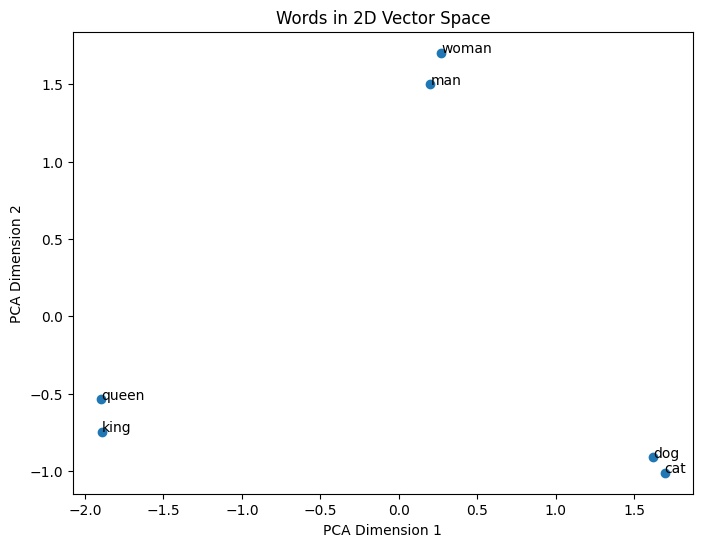

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Words we want to visualize
words_to_plot = [
    "cat",
    "dog",
    "king",
    "queen",
    "man",
    "woman"
]

# Get their word vectors
word_vectors = [
    model[word]
    for word in words_to_plot
]

# Convert list to array
import numpy as np

word_vectors = np.array(word_vectors)

print("Original shape:")
print(word_vectors.shape)

# Reduce dimensions to 2D
pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(word_vectors)

print("\n2D shape:")
print(vectors_2d.shape)


# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

# Add word labels
for i, word in enumerate(words_to_plot):

    plt.annotate(
        word,
        (
            vectors_2d[i, 0],
            vectors_2d[i, 1]
        )
    )

plt.title("Words in 2D Vector Space")

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.show()